(a) Significance of the Multiplicative Model
An image can be expressed as: f (x, y)= i(x, y)· r(x, y),

i(x, y) : Illumination (slowly varying, low-frequency component).

r(x, y) : Reflectance (object details, edges, texture — high-frequency component).

This model captures the fact that uneven lighting (illumination) interacts multiplicatively with the true scene reflectance.

The challenge: illumination dominates low frequencies, while reflectance dominates high frequencies. Separating them allows us to correct lighting without destroying details.


(b) Logarithmic Transformation
Taking the logarithm converts multiplication into addition:
ln[f (x, y)]= ln[i(x, y)]+ln[r(x, y)],
Now illumination and reflectance are additive components.
This makes it possible to apply frequency-domain filtering to suppress illumination (low-frequency) and enhance reflectance (high-frequency).

(c) Algorithm / Pseudo-code for Homomorphic Filtering

In [2]:
import cv2 as cv
import numpy as np

def homomorphic_filter(img, gammaL=0.5, gammaH=2.0, c=1.0, D0=30):
    # Step 1: log transform
    img_log = np.log1p(np.array(img, dtype="float"))
    
    # Step 2: FFT
    fft = np.fft.fft2(img_log)
    fft_shift = np.fft.fftshift(fft)
    
    # Step 3: Construct filter
    rows, cols = img.shape
    u, v = np.meshgrid(np.arange(-cols//2, cols//2), np.arange(-rows//2, rows//2))
    D = np.sqrt(u**2 + v**2)
    H = (gammaH - gammaL) * (1 - np.exp(-c*(D**2 / (D0**2)))) + gammaL
    
    # Step 4: Apply filter
    S = H * fft_shift
    
    # Step 5: Inverse FFT
    s = np.fft.ifftshift(S)
    img_ifft = np.fft.ifft2(s)
    img_out = np.real(img_ifft)
    
    # Step 6: Exponentiation
    img_exp = np.expm1(img_out)
    img_exp = cv.normalize(img_exp, None, 0, 255, cv.NORM_MINMAX)
    return np.uint8(img_exp)


(d) Compare homomorphic filtering with histogram equalization.

Homomorphic Filtering	                                                    Histogram Equalization
Frequency-domain filtering	                                                Spatial-domain intensity remapping
Separates illumination (low-freq) and reflectance (high-freq)	            Redistributes pixel intensities for uniform histogram
Corrects uneven lighting, enhances contrast	                                Enhances global contrast
Computationally heavier, may introduce ringing artifacts	                Can over-enhance noise, doesn’t correct illumination

Preferred Situation :
Non-uniform illumination, shading correction	                            Low-contrast images with uniform lighting

(e) Apply the method to an image of your choice and briefly comment on:
• Illumination correction
• Contrast enhancement
• Any artifacts observed

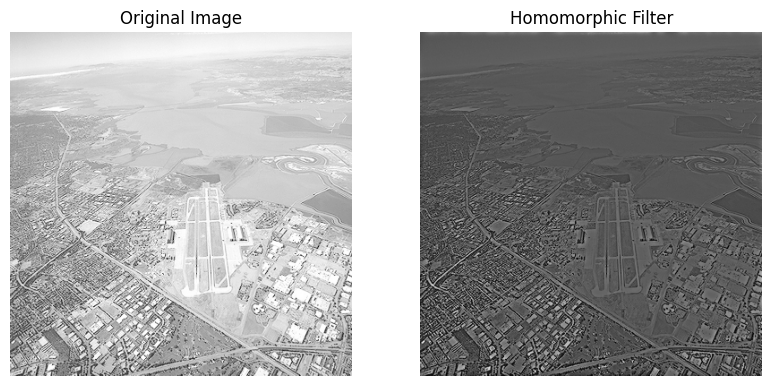

In [3]:
import matplotlib.pyplot as plt

# Load an image (grayscale or color)
img = cv.imread('/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 01/runway.png', cv.IMREAD_REDUCED_GRAYSCALE_2)
assert img is not None


filter = homomorphic_filter(img, gammaL=0.5, gammaH=2.0, c=1.0, D0=30)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")


plt.subplot(1,3,2)
plt.title("Homomorphic Filter")
plt.imshow(filter, cmap='gray')
plt.axis("off")
plt.show()



Illumination correction: Uneven lighting (e.g., shadows, bright spots) is suppressed.
Contrast enhancement: Details and edges become sharper due to high-frequency boosting.
Artifacts: Possible ringing near edges, or unnatural contrast if parameters are poorly tuned.